# SSM Quantization Stability (Deep Learning Course Project, Spring2026)

## Code

This notebook contains the code to run experiments for our project.

## Attribution
`S4Model` is taken from the S4 repository
(HazyResearch/state-spaces, Apache-2.0; `s4/example.py`); `discretize`, the conv
FFT, and the `SSMLayer` recurrence are adapted from `s4/models/s4/s4d.py` and
`s4/models/s4/s4.py`.


In [1]:
import copy
import csv
import math
import os
import sys
from dataclasses import dataclass
from datetime import datetime

import torch
import torch.nn as nn
import numpy as np
import torchvision
import torchvision.transforms as transforms
import matplotlib
if "ipykernel" not in sys.modules:         
    matplotlib.use("Agg")

import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # MPS excluded (complex)
print("device:", device)

device: cpu


## Quantizers

Zhao et al. implement fake-quantization described in Jacob et al. (2018). You can read algorithms of different quantizers, but most important are:
- `fake_quant_complex_asym` aka `cartesian-asym (the scheme Zhao et al. use)
- `fake_quant_logpolar`/`fake_quant_logpolar_r1` aka `logpolar`/`logpolar-r1` (the scheme we propose)

In [2]:
def fake_quant(x, bits, per_head=True):
    """Uniform symmetric fake-quantization of a REAL tensor, optionally per S4D head. 
        Maps all values into grid [-qmax-1, qmax] with cells `scale`.
        Notice that this scheme always has a zero point 
        (torch.round(x/scale) = 0 for abs(x) < scale)"""
    maxval = x.abs().amax(dim=-1, keepdim=True) if per_head else x.abs().amax()
    qmax = 2 ** (bits - 1) - 1
    scale = (maxval / qmax).clamp(min=1e-12)
    q = torch.clamp(torch.round(x / scale), -qmax - 1, qmax)
    return q * scale


def fake_quant_complex(z, bits):
    return torch.complex(fake_quant(z.real, bits), fake_quant(z.imag, bits))


def fake_quant_asym(x, bits, per_head=True):
    """Asymmetric fake-quantization of a REAL tensor, optionally per S4D head.
        Fits the grid to the OBSERVED range [lo, hi] = [min, max] instead of a symmetric
        [-max, max], so it wastes no cells when the values are one-sided -- e.g. Re(A)
        clusters near +1, where a symmetric grid would spend half its levels on the empty
        negative side. .
        The integer zero-point zp = round(-lo/scale) shifts the grid so that x = 0 lands
        a grid point (q = zp)"""
    if per_head:
        lo, hi = x.amin(dim=-1, keepdim=True), x.amax(dim=-1, keepdim=True)
    else:
        lo, hi = x.amin(), x.amax()
    levels = 2 ** bits - 1
    scale = ((hi - lo) / levels).clamp(min=1e-12)
    zp = torch.round(-lo / scale)
    q = torch.clamp(torch.round(x / scale) + zp, 0, levels)
    return (q - zp) * scale


def fake_quant_complex_asym(z, bits):
    return torch.complex(fake_quant_asym(z.real, bits), fake_quant_asym(z.imag, bits))


def quant_uniform(x, lo, hi, bits):
    """Uniform grid on [lo, hi] (scalars or broadcastable per-head tensors).
        Has zero point (when abs(x -lo) < scale )"""
    levels = 2 ** bits - 1
    scale = torch.as_tensor((hi - lo) / levels, dtype=x.dtype, device=x.device).clamp(min=1e-12)
    q = torch.clamp(torch.round((x - lo) / scale), 0, levels)
    return lo + q * scale


def quant_phase(theta, bits, per_head=True):
    """Phase quantized over its OBSERVED per-head range (puts theta=0 on the grid and 
    doesnt waste bits for values that are never realized by theta"""
    if per_head:
        t_lo, t_hi = theta.amin(dim=-1, keepdim=True), theta.amax(dim=-1, keepdim=True)
    else:
        t_lo, t_hi = theta.amin(), theta.amax()
    return quant_uniform(theta, t_lo, t_hi, bits)


def fake_quant_polar(z, bits=None, eps=1e-6, per_head=True, calibrate_phase=True,
                     bits_r=None, bits_theta=None):
    """Polar: quantize magnitude and
    phase separately. bits_r/bits_theta override `bits` per coordinate.
    `bits_r == bits_theta == None`: each of the parameters quantized to `bits`"""
    if bits_r is None and bits_theta is None:
        bits_r = bits_theta = bits
    r, theta = z.abs(), torch.angle(z)
    if bits_r is not None:
        r_hi = r.amax(dim=-1, keepdim=True) if per_head else r.amax().clamp(max=1 - eps)
        r = quant_uniform(r, 0.0, r_hi, bits_r)
    if bits_theta is not None:
        theta = quant_phase(theta, bits_theta, per_head) if calibrate_phase \
            else quant_uniform(theta, -math.pi, math.pi, bits_theta)
    return r * torch.exp(1j * theta)


def fake_quant_logpolar(z, bits=None, eps=1e-6, per_head=True, calibrate_phase=True,
                        bits_r=None, bits_theta=None):
    """Log-polar: quantize s = log(1-r) instead of r. You can read in our report why this works so
    well for A"""
    if bits_r is None and bits_theta is None:
        bits_r = bits_theta = bits
    r, theta = z.abs(), torch.angle(z)
    if bits_r is not None:
        s = torch.log((1 - r).clamp(min=eps))
        if per_head:
            s_lo, s_hi = s.amin(dim=-1, keepdim=True), s.amax(dim=-1, keepdim=True)
        else:
            s_lo, s_hi = s.amin(), s.amax()
        r = 1 - torch.exp(quant_uniform(s, s_lo, s_hi, bits_r))
    if bits_theta is not None:
        theta = quant_phase(theta, bits_theta, per_head) if calibrate_phase \
            else quant_uniform(theta, -math.pi, math.pi, bits_theta)
    return r * torch.exp(1j * theta)


def fake_quant_polar_bad(z, bits):       
    """Uncalibrated [-pi,pi] phase grid"""
    return fake_quant_polar(z, bits, calibrate_phase=False)


def fake_quant_logpolar_bad(z, bits):
    """Uncalibrated [-pi,pi] phase grid"""
    return fake_quant_logpolar(z, bits, calibrate_phase=False)


def fake_quant_complex_proj(z, bits, eps=1e-4):
    """Cartesian quantization, bring |z_q|>=1 back onto the disk.
    Fixes instability but doesn't fix resolution mismatch (most of the bits go to space that isn't
    realized)"""
    zq = fake_quant_complex(z, bits)
    r = zq.abs()
    mask = r >= 1.0
    if mask.any():
        zq = torch.where(mask, zq / r.clamp(min=1e-12) * (1 - eps), zq)
    return zq


def fake_quant_magonly(z, bits):    return fake_quant_polar(z, bits_r=bits)     # phase exact
def fake_quant_logmagonly(z, bits): return fake_quant_logpolar(z, bits_r=bits)
def fake_quant_phaseonly(z, bits):  return fake_quant_polar(z, bits_theta=bits)  # magnitude exact
def fake_quant_logpolar_r1(z, bits): return fake_quant_logpolar(z, bits_r=1, bits_theta=2 * bits - 1)


def fake_quant_logpolar_r0(z, bits, eps=1e-6):
    """Zero radius bits, it's a constant that equals to arithmetic average of min and max. The whole budget goes to phase."""
    r, theta = z.abs(), torch.angle(z)
    s = torch.log((1 - r).clamp(min=eps))
    s_mid = (s.amin(dim=-1, keepdim=True) + s.amax(dim=-1, keepdim=True)) / 2
    return (1 - torch.exp(s_mid)) * torch.exp(1j * quant_phase(theta, 2 * bits, per_head=True))


def fake_quant_unitary(z, bits):
    """r = 1 for every mode (orthogonal-RNN limit): pure rotation, whole budget to phase."""
    return torch.polar(torch.ones_like(z.abs()), quant_phase(torch.angle(z), 2 * bits, per_head=True))


QUANTIZERS = {
    "cartesian": fake_quant_complex, "cartesian-asym": fake_quant_complex_asym,
    "cartesian-proj": fake_quant_complex_proj, "polar": fake_quant_polar,
    "logpolar": fake_quant_logpolar, "polar-bad": fake_quant_polar_bad,
    "logpolar-bad": fake_quant_logpolar_bad, "mag-only": fake_quant_magonly,
    "logmag-only": fake_quant_logmagonly, "phase-only": fake_quant_phaseonly,
    "logpolar-r1": fake_quant_logpolar_r1, "logpolar-r0": fake_quant_logpolar_r0,
    "unitary": fake_quant_unitary,
}
print("schemes:", list(QUANTIZERS))

schemes: ['cartesian', 'cartesian-asym', 'cartesian-proj', 'polar', 'logpolar', 'polar-bad', 'logpolar-bad', 'mag-only', 'logmag-only', 'phase-only', 'logpolar-r1', 'logpolar-r0', 'unitary']


## State quantization (dynamic per-head asymmetric)

The state is an activation: quantize it per forward with fake_quant_complex_asym, whose
per-head range is read live from the current state (dynamic), so nothing is clipped away.

In [3]:
def quant_state(x, bits):
    return fake_quant_complex_asym(x, bits)

def discretize(kernel):
    """ZOH discretization of the S4D kernel -> (dA, dB, dC).
    dA = exp(A*dt); dB = (dA-1)/A (folds B=1); dC from the complex C parameter.
    """
    dt = torch.exp(kernel.log_dt)
    A = -torch.exp(kernel.log_A_real) + 1j * kernel.A_imag
    dA = torch.exp(A * dt.unsqueeze(-1))
    dB = (dA - 1.) / A
    dC = torch.view_as_complex(kernel.C)
    return dA, dB, dC




## QuantConfig

This config contains all quantization parameters we use 

In [4]:
@dataclass
class QuantConfig:
    """All quantization knobs for one forward pass (fp when every field is left default)."""
    scheme: object = None        # Ā grid: a name in QUANTIZERS, a callable, or None (fp)
    a_bits: int = None           # bits for Ā (per coordinate); None = fp
    bcd_bits: int = 4 # bits for B̄/C̄/D (asymmetric); None = fp
    x_bits: int = None           # bits for the recurrent state; None = fp



## Model (S4Model backbone; the S4D layer is the vendored library)

In [5]:
sys.path.insert(0, os.path.join(os.getcwd(), "s4"))
from models.s4.s4d import S4D

class S4Model(nn.Module):
    def __init__(self, d_input, d_output=10, d_model=16, n_layers=4, dropout=0.1, prenorm=False):
        super().__init__()
        self.prenorm = prenorm
        self.encoder = nn.Linear(d_input, d_model)
        self.s4_layers, self.norms, self.dropouts = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        for _ in range(n_layers):
            self.s4_layers.append(S4D(d_model, dropout=dropout, transposed=True, lr=0.001))
            self.norms.append(nn.LayerNorm(d_model))
            self.dropouts.append(nn.Dropout1d(dropout))
        self.decoder = nn.Linear(d_model, d_output)

    def forward(self, x):                    # the vendored conv-mode forward (for loading only)
        x = self.encoder(x).transpose(-1, -2)
        for layer, norm, dropout in zip(self.s4_layers, self.norms, self.dropouts):
            z = x
            if self.prenorm:
                z = norm(z.transpose(-1, -2)).transpose(-1, -2)
            z, _ = layer(z)
            x = dropout(z) + x
            if not self.prenorm:
                x = norm(x.transpose(-1, -2)).transpose(-1, -2)
        return self.decoder(x.transpose(-1, -2).mean(dim=1))

In [6]:
from torchinfo import summary
m = S4Model(1, 10, 16, 4)                 # d_input=1, d_output=10, d_model=16, n_layers=4
summary(m, input_size=(1, 784, 1),        # (batch, seq_len, d_input)
        col_names=("input_size", "output_size", "num_params"),
        depth=4, device="cpu")

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
S4Model                                  [1, 784, 1]               [1, 10]                   --
├─Linear: 1-1                            [1, 784, 1]               [1, 784, 16]              32
├─ModuleList: 1-11                       --                        --                        (recursive)
│    └─S4D: 2-1                          [1, 16, 784]              [1, 16, 784]              16
│    │    └─S4DKernel: 3-1               --                        [16, 784]                 2,064
│    │    └─GELU: 3-2                    [1, 16, 784]              [1, 16, 784]              --
│    │    └─DropoutNd: 3-3               [1, 16, 784]              [1, 16, 784]              --
│    │    └─Sequential: 3-4              [1, 16, 784]              [1, 16, 784]              --
│    │    │    └─Conv1d: 4-1             [1, 16, 784]              [1, 32, 784]              544
│    │    │    └─GLU: 

## PTQ+QAT machinery

In [7]:
CAPPED_SCHEMES = ("polar", "logpolar", "polar-bad", "logpolar-bad")

def apply_q(fn, x, *args):
    """Quantize x with fn but pass gradients straight through (STE): forward = fn(x),
    backward = identity. """
    return x + (fn(x.detach(), *args) - x).detach()

def cap_disk(z, eps=1e-4):
    r = z.abs()
    return torch.where(r >= 1 - eps, z / r.clamp(min=1e-12) * (1 - eps), z)


def _ssm_scan(dA, dB, dC, u, x_bits=None, diag=None, trace=None, observe=None):
    """The _ssm_scan function adapted from S4 repo"""
    B, H, L = u.shape
    x = torch.zeros(B, H, dA.shape[-1], dtype=torch.cfloat, device=u.device)
    ys = []
    for t in range(L):
        x = dA * x + dB * u[..., t].unsqueeze(-1) # can do dA * x because dA is diagonal
        if x_bits is not None:
            x = apply_q(quant_state, x, x_bits)
        if observe is not None:
            observe(x)
        if diag is not None:
            m = x.abs().amax().item()
            diag["maxX"] = max(diag.get("maxX", 0.0), m if math.isfinite(m) else 1e30)
        if trace is not None:
            trace.append(min(x.abs().amax().item(), 1e30))
        ys.append(2 * torch.einsum('hn,bhn->bh', dC, x).real)
    return torch.stack(ys, -1)


class SSMLayer(nn.Module):
    """One diagonal S4D block as explicit discrete matrices (dA, dB, dC, D) + GLU tail.

    Single implementation for PTQ (eval) and QAT (training).
    The matrices are stored fp and quantized per-forward from a QuantConfig, so one model
    sweeps every scheme. `train_a` makes Ā trainable (with quantization gradient computed as an identity function, method
    known as STE - straight-throught gradient estimator)"""

    def __init__(self, layer, train_a=False):
        super().__init__()
        self.train_a = train_a
        with torch.no_grad():
            dA, dB, dC = discretize(layer.kernel)
        self.dA = nn.Parameter(torch.view_as_real(dA.clone()), requires_grad=train_a)
        self.dB = nn.Parameter(torch.view_as_real(dB.clone()))
        self.dC = nn.Parameter(torch.view_as_real(dC.clone()))
        self.D = nn.Parameter(layer.D.detach().clone())
        self.activation, self.dropout, self.output_linear = \
            layer.activation, layer.dropout, layer.output_linear

    def matrices(self, cfg):
        """Quantized (dA, dB, dC, D) for one forward. """
        dA = torch.view_as_complex(self.dA)
        if self.train_a and cfg.scheme in CAPPED_SCHEMES:
            dA = cap_disk(dA)
        if cfg.scheme is not None and cfg.a_bits is not None:
            q = QUANTIZERS[cfg.scheme] if isinstance(cfg.scheme, str) else cfg.scheme
            dA = apply_q(q, dA, cfg.a_bits)
        dB, dC, D = torch.view_as_complex(self.dB), torch.view_as_complex(self.dC), self.D
        if cfg.bcd_bits is not None:
            dB = apply_q(fake_quant_complex_asym, dB, cfg.bcd_bits)
            dC = apply_q(fake_quant_complex_asym, dC, cfg.bcd_bits)
            D = apply_q(fake_quant_asym, D, cfg.bcd_bits, False)   # per_head=False
        return dA, dB, dC, D

    def forward(self, u, cfg, mode="rec", diag=None, trace=None, observe=None):
        """The forward function adapted from S4 repo"""

        dA, dB, dC, D = self.matrices(cfg)
        if diag is not None:
            diag["maxA"] = max(diag.get("maxA", 0.0), dA.abs().amax().item())
        if mode == "conv":
            L = u.size(-1)
            lpow = dA.unsqueeze(-1) ** torch.arange(L, device=u.device)
            K = 2 * torch.einsum('hn,hnl->hl', dC * dB, lpow).real
            y = torch.fft.irfft(torch.fft.rfft(u, n=2 * L) * torch.fft.rfft(K, n=2 * L), n=2 * L)[..., :L]
        else:
            y = _ssm_scan(dA, dB, dC, u, x_bits=cfg.x_bits, diag=diag, trace=trace, observe=observe)
        return self.output_linear(self.dropout(self.activation(y + u * D.unsqueeze(-1))))


class SSMModel(nn.Module):
    """The whole S4D classifier as SSMLayers. One forward serves both eval and training,
    conv or recurrent. Built from a loaded S4Model (which holds the trained weights)."""

    def __init__(self, base, train_a=False):
        super().__init__()
        b = copy.deepcopy(base)
        self.encoder, self.decoder = b.encoder, b.decoder
        self.norms, self.dropouts = b.norms, b.dropouts
        self.layers = nn.ModuleList(SSMLayer(l, train_a) for l in b.s4_layers)

    def forward(self, u, cfg=None, mode="rec", diag=None, trace=None, observe=None):
        cfg = cfg if cfg is not None else QuantConfig()
        x = self.encoder(u).transpose(-1, -2)
        for i, (layer, norm, drop) in enumerate(zip(self.layers, self.norms, self.dropouts)):
            obs = observe[i] if isinstance(observe, (list, tuple)) else observe
            z = layer(x, cfg, mode=mode, diag=diag, trace=trace, observe=obs)
            x = norm((drop(z) + x).transpose(-1, -2)).transpose(-1, -2)
        return self.decoder(x.transpose(-1, -2).mean(dim=1))

    @torch.no_grad()
    def max_absA(self, cfg=None):
        cfg = cfg if cfg is not None else QuantConfig()
        return max(l.matrices(cfg)[0].abs().amax().item() for l in self.layers)


RESULTS_CSV = "results/experiments.csv"
_CSV_FIELDS = ["name", "phase", "scheme", "a_bits", "bcd_bits", "x_bits",
               "lr", "epochs", "acc", "peak_absA", "maxA", "maxX"]

def log_result(name, phase, cfg, **metrics):
    os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)
    scheme = cfg.scheme if isinstance(cfg.scheme, str) else getattr(cfg.scheme, "__name__", repr(cfg.scheme))
    row = dict.fromkeys(_CSV_FIELDS, "")
    row.update(name=name, phase=phase,
               scheme=scheme, a_bits=cfg.a_bits, bcd_bits=cfg.bcd_bits, x_bits=cfg.x_bits, **metrics)
    write_header = not os.path.exists(RESULTS_CSV)
    with open(RESULTS_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=_CSV_FIELDS)
        if write_header:
            w.writeheader()
        w.writerow(row)
    return row


@torch.no_grad()
def accuracy(name, model, loader, limit=1000, cfg=None, mode="rec"):
    """Test accuracy (%) + the diag dict (maxA / maxX); logs a PTQ row named `name`."""
    model.eval()
    correct = total = 0
    diag = {}
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb, cfg=cfg, mode=mode, diag=diag)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
        if total >= limit:
            break
    acc = 100.0 * correct / total
    cfg = cfg if cfg is not None else QuantConfig()
    log_result(name, "ptq", cfg, acc=round(acc, 3),
               maxA=round(diag.get("maxA", float("nan")), 6),   # maxX absent in conv mode: expected
               maxX=round(diag.get("maxX", float("nan")), 4))
    return acc, diag


def train_qat(name, model, loader, cfg, epochs, lr, train_limit):
    """Fine-tune (no gradient clipping). Returns peak max|A_bar_q| and logs a QAT-train row.
    Only requires_grad leaves are optimized, so frozen-Ā vs trainable-Ā is one flag
    on the model (SSMLayer.train_a)."""
    model.train()
    opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)
    crit = nn.CrossEntropyLoss()
    maxA_peak = model.max_absA(cfg)
    for ep in range(epochs):
        seen = 0
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            opt.zero_grad()
            crit(model(inputs, cfg=cfg), targets).backward()
            opt.step()
            maxA_peak = max(maxA_peak, model.max_absA(cfg))
            seen += targets.size(0)
            if train_limit is not None and seen >= train_limit:
                break
    log_result(name, "qat_train", cfg, lr=lr, epochs=epochs, peak_absA=round(maxA_peak, 6))
    return maxA_peak


SCHEMES_MAIN = ["cartesian-asym", "cartesian-proj", "polar", "logpolar", "logpolar-r1", "unitary"]

# Load data + model

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(1, 784).t()),
])
testset = torchvision.datasets.MNIST("s4/data", train=False, download=True, transform=transform)
trainset = torchvision.datasets.MNIST("s4/data", train=True, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=250, num_workers=0)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=0)

base = S4Model(1, 10, 16, 4, 0.1, False).to(device)      # vendored backbone, holds the trained weights
ckpt = torch.load("s4/checkpoint/ckpt.pth", map_location="cpu")
base.load_state_dict(ckpt["model"])
base.eval()
model = SSMModel(base).to(device)                        # unified PTQ/QAT model over discrete matrices
model.eval()
print(f"loaded baseline: val acc {ckpt['acc']:.2f}% @ epoch {ckpt['epoch']}")





loaded baseline: val acc 98.77% @ epoch 26


## Eigenvalue distribution + stability table



In [9]:
print(f"let N=1/(1-r) (memory time constant)")
for i, layer in enumerate(model.layers):
    r = layer.matrices(QuantConfig())[0].abs().flatten()
    
    N = 1 / (1 - r).clamp(min=1e-9)
    
    b = [(N < 10).float().mean(), ((N >= 10) & (N < 100)).float().mean(),
         ((N >= 100) & (N < 1000)).float().mean(), (N >= 1000).float().mean()]
    print(f"layer {i}: fast {b[0]:.0%} (N<10) med {b[1]:.0%} (100>N>=10) slow {b[2]:.0%} (1000>N>=100) v.slow {b[3]:.0%} (N>=1000) "
          f"| |A| median {r.median():.4f} max {r.max():.5f}")

let N=1/(1-r) (memory time constant)
layer 0: fast 0% (N<10) med 28% (100>N>=10) slow 56% (1000>N>=100) v.slow 16% (N>=1000) | |A| median 0.9966 max 0.99951
layer 1: fast 0% (N<10) med 41% (100>N>=10) slow 51% (1000>N>=100) v.slow 8% (N>=1000) | |A| median 0.9952 max 0.99951
layer 2: fast 0% (N<10) med 31% (100>N>=10) slow 49% (1000>N>=100) v.slow 20% (N>=1000) | |A| median 0.9954 max 0.99950
layer 3: fast 0% (N<10) med 59% (100>N>=10) slow 41% (1000>N>=100) v.slow 0% (N>=1000) | |A| median 0.9863 max 0.99897


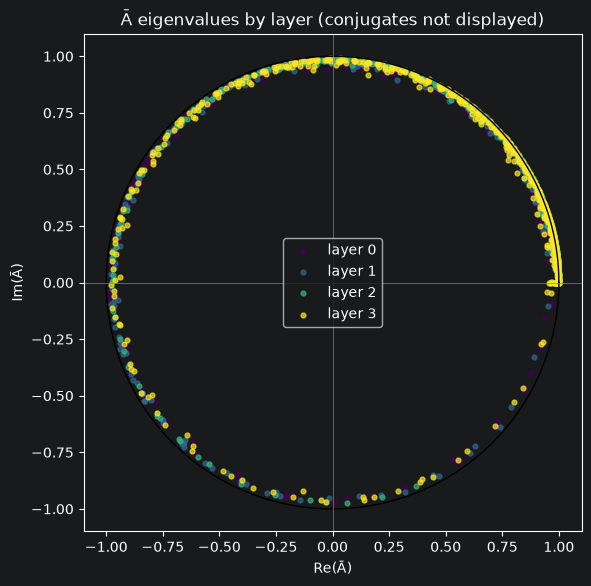

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

th = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(th), np.sin(th), 'k-', lw=1)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

colors = plt.cm.viridis(np.linspace(0, 1, len(model.layers)))
for i, layer in enumerate(model.layers):
    dA = layer.matrices(QuantConfig())[0].detach().cpu().numpy()
    ax.scatter(dA.real.ravel(), dA.imag.ravel(),
               s=12, color=colors[i], alpha=0.7, label=f"layer {i}")

ax.set_aspect('equal')
ax.set_xlabel("Re(Ā)"); ax.set_ylabel("Im(Ā)")
ax.set_title("Ā eigenvalues by layer (conjugates not displayed)")
ax.legend()
plt.tight_layout(); plt.show()

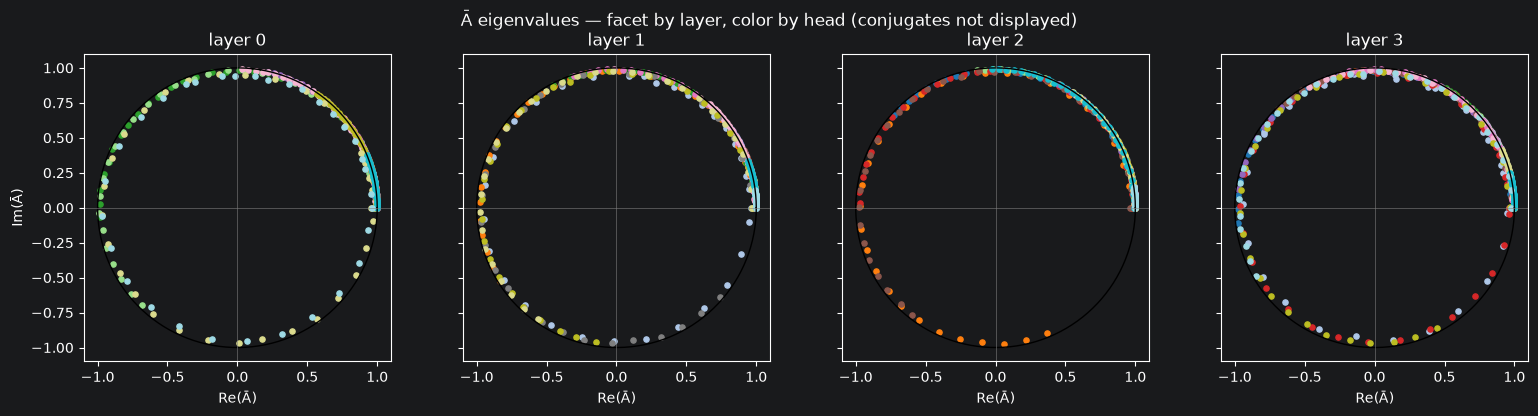

In [11]:
n = len(model.layers)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharex=True, sharey=True)
th = np.linspace(0, 2 * np.pi, 400)
head_colors = plt.cm.tab20(np.linspace(0, 1, 16))          # 16 head colors

for i, (ax, layer) in enumerate(zip(axes, model.layers)):
    dA = layer.matrices(QuantConfig())[0].detach().numpy()   # (H, N) complex
    ax.plot(np.cos(th), np.sin(th), 'k-', lw=1)
    ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
    for h in range(dA.shape[0]):
        ax.scatter(dA[h].real, dA[h].imag, s=14, color=head_colors[h])
    ax.set_aspect('equal'); ax.set_title(f"layer {i}"); ax.set_xlabel("Re(Ā)")

axes[0].set_ylabel("Im(Ā)")
fig.suptitle("Ā eigenvalues — facet by layer, color by head (conjugates not displayed)")
plt.tight_layout()
plt.show()

## Maximum eigenvalue in different quantization schemes

In [12]:
print(f"{'scheme':>16} | " + " | ".join(f"{bb}b" for bb in [8, 6, 4]))
for s in SCHEMES_MAIN:
    print(f"{s:>16} | " + " | ".join(
        f"{model.max_absA(QuantConfig(scheme=s, a_bits=bb)):.4f}" for bb in [8, 6, 4]))

          scheme | 8b | 6b | 4b
  cartesian-asym | 0.9995 | 1.0039 | 1.0514
  cartesian-proj | 1.0000 | 1.0000 | 1.0000
           polar | 0.9995 | 0.9995 | 0.9995
        logpolar | 0.9995 | 0.9995 | 0.9995
     logpolar-r1 | 0.9995 | 0.9995 | 0.9995
         unitary | 1.0000 | 1.0000 | 1.0000


# Experiments for non-quantized state $x$

## PTQ scheme comparison

In [13]:
probe = next(iter(test_loader))[0][:32].to(device)
print(f"{'scheme':>16} | {'bits':>4} | {'acc%':>6} | {'max|A|':>7} | stable")
for s in ["(fp)"] + SCHEMES_MAIN + ["polar-bad"] + ["logpolar-bad"]:
    for bb in ([None] if s == "(fp)" else [16,8,7,6]):
        cfg = QuantConfig(scheme=(None if s == "(fp)" else s), a_bits=bb)
        acc, diag = accuracy(f"ptq_{s}_{bb}b", model, test_loader, cfg=cfg)
        mA = diag.get("maxA", model.max_absA(cfg))
        print(f"{s:>16} | {str(bb):>4} | {acc:>6.2f} | {mA:>7.4f} | {'yes' if mA <= 1 else 'NO'}")
cfg = QuantConfig(scheme="logpolar", a_bits=8)
with torch.no_grad():
    yc = model(probe, cfg=cfg, mode="conv")
    yr = model(probe, cfg=cfg, mode="rec")
print(f"conv vs rec (logpolar@8): logit diff {(yc - yr).abs().max():.2e}, "
      f"agreement {(yc.argmax(1) == yr.argmax(1)).float().mean():.0%}")

          scheme | bits |   acc% |  max|A| | stable
            (fp) | None |  98.20 |  0.9995 | yes
  cartesian-asym |   16 |  98.20 |  0.9995 | yes
  cartesian-asym |    8 |  97.00 |  0.9995 | yes
  cartesian-asym |    7 |  94.80 |  0.9995 | yes
  cartesian-asym |    6 |  63.30 |  1.0039 | NO
  cartesian-proj |   16 |  98.20 |  0.9995 | yes
  cartesian-proj |    8 |  92.60 |  1.0000 | yes
  cartesian-proj |    7 |  92.20 |  1.0000 | yes
  cartesian-proj |    6 |  61.80 |  1.0000 | yes
           polar |   16 |  98.20 |  0.9995 | yes
           polar |    8 |  98.10 |  0.9995 | yes
           polar |    7 |  97.50 |  0.9995 | yes
           polar |    6 |  77.10 |  0.9995 | yes
        logpolar |   16 |  98.20 |  0.9995 | yes
        logpolar |    8 |  98.30 |  0.9995 | yes
        logpolar |    7 |  97.40 |  0.9995 | yes
        logpolar |    6 |  92.30 |  0.9995 | yes
     logpolar-r1 |   16 |  97.30 |  0.9995 | yes
     logpolar-r1 |    8 |  97.30 |  0.9995 | yes
     logpolar-r1 |

## Only cartesian-asym vs logpolar-1 (one bit to magnitude, the rest to phase)

In [14]:
probe = next(iter(test_loader))[0][:32].to(device)
print(f"{'scheme':>16} | {'bits':>4} | {'acc%':>6} | {'max|A|':>7} | stable")
for s in ["(fp)"] + ["cartesian-asym", "logpolar-r1"]:
    for bb in ([None] if s == "(fp)" else [8, 7, 6,5, 4]):
        cfg = QuantConfig(scheme=(None if s == "(fp)" else s), a_bits=bb)
        acc, diag = accuracy(f"ptq_{s}_{bb}b", model, test_loader, cfg=cfg)
        mA = diag.get("maxA", model.max_absA(cfg))
        print(f"{s:>16} | {str(bb):>4} | {acc:>6.2f} | {mA:>7.4f} | {'yes' if mA <= 1 else 'NO'}")
cfg = QuantConfig(scheme="logpolar", a_bits=8)
with torch.no_grad():
    yc = model(probe, cfg=cfg, mode="conv")
    yr = model(probe, cfg=cfg, mode="rec")

          scheme | bits |   acc% |  max|A| | stable
            (fp) | None |  98.20 |  0.9995 | yes
  cartesian-asym |    8 |  97.00 |  0.9995 | yes
  cartesian-asym |    7 |  94.80 |  0.9995 | yes
  cartesian-asym |    6 |  63.30 |  1.0039 | NO
  cartesian-asym |    5 |   9.90 |  1.0177 | NO
  cartesian-asym |    4 |   9.90 |  1.0514 | NO
     logpolar-r1 |    8 |  97.30 |  0.9995 | yes
     logpolar-r1 |    7 |  97.30 |  0.9995 | yes
     logpolar-r1 |    6 |  97.30 |  0.9995 | yes
     logpolar-r1 |    5 |  96.90 |  0.9995 | yes
     logpolar-r1 |    4 |  94.10 |  0.9995 | yes


## Streaming divergence (max|state| over 4x sequence length)

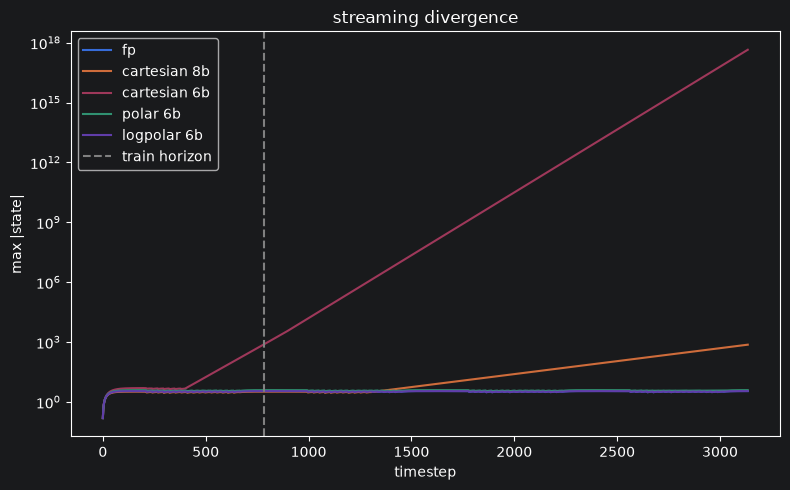

In [15]:
xin = model.encoder(probe[:16].repeat(1, 4, 1)).transpose(-1, -2)
plt.figure(figsize=(8, 5))
for label, s, b in [("fp", None, None), ("cartesian 8b", "cartesian", 8),
                    ("cartesian 6b", "cartesian", 6), ("polar 6b", "polar", 6),
                    ("logpolar 6b", "logpolar", 6)]:
    tr = []
    with torch.no_grad():
        model.layers[0](xin, QuantConfig(scheme=s, a_bits=b), mode="rec", trace=tr)
    plt.semilogy(tr, label=label)
plt.axvline(784, color="gray", ls="--", label="train horizon")
plt.xlabel("timestep"); plt.ylabel("max |state|"); plt.legend(); plt.title("streaming divergence")
plt.tight_layout(); plt.show()

In [16]:
import copy, torch
import torch.nn as nn

xb, yb = next(iter(train_loader)); xb, yb = xb.to(device), yb.to(device)
crit = nn.CrossEntropyLoss()

def probe_layer_no_norm(target_max, k=3, L=784):
    layer = copy.deepcopy(model.layers[k]).to(device)
    layer.requires_grad_(True)
    with torch.no_grad():                                        # destabilize this layer's Ā
        d = torch.view_as_complex(layer.dA); d.mul_(target_max / d.abs().amax())
        layer.dA.copy_(torch.view_as_real(d))
    u = model.encoder(xb[:, :L, :]).transpose(-1, -2).detach()   # layer input (B,H,L)
    y = layer(u, QuantConfig())                                  # SSMLayer.forward -> (B,H,L), NO norm
    logits = model.decoder(y.transpose(-1, -2).mean(dim=1))      # (B,H,L)->(B,L,H)->mean->(B,H)->(B,10)
    loss = crit(logits, yb)                                      # cross-entropy
    layer.zero_grad(set_to_none=True)
    loss.backward()
    return layer.dA.grad.norm().item()

def probe_layer_norm(target_max, k=3, L=784):
    m = copy.deepcopy(model)                 # fresh copy; train_a stays False -> no cap_disk
    m.requires_grad_(True)
    with torch.no_grad():                    # rescale layer-0 eigenvalues to max|A| = target_max
        d = torch.view_as_complex(m.layers[k].dA)
        d.mul_(target_max / d.abs().amax())
        m.layers[0].dA.copy_(torch.view_as_real(d))
    diag = {}
    m.zero_grad(set_to_none=True)
    xin = xb[:, :L, :]
    logits = m(xin, cfg=QuantConfig(), diag=diag)
    loss = crit(logits, yb)
    loss.backward()
    return diag.get("maxX"), m.layers[0].dA.grad.norm().item()

print("--- sweep max|A|---")
for s in [0.99, 0.999, 1.0, 1.003, 1.01, 1.05,1.06]:
    k=3
    maxX, g = probe_layer_norm(s, k=k)
    print(f"max|A|={s:.3f}  maxX={maxX:.2e}  ||dA.grad||(with norm+res+drop)={g:.3e} "
          f"||dA.grad||(raw)={probe_layer_no_norm(s, k=k):.3e}")

--- sweep max|A|---
max|A|=0.990  maxX=1.31e+01  ||dA.grad||(with norm+res+drop)=2.069e+02 ||dA.grad||(raw)=8.079e+02
max|A|=0.999  maxX=5.40e+01  ||dA.grad||(with norm+res+drop)=5.333e+02 ||dA.grad||(raw)=2.594e+03
max|A|=1.000  maxX=7.37e+01  ||dA.grad||(with norm+res+drop)=5.602e+02 ||dA.grad||(raw)=8.247e+03
max|A|=1.003  maxX=2.55e+02  ||dA.grad||(with norm+res+drop)=9.215e+02 ||dA.grad||(raw)=3.151e+04
max|A|=1.010  maxX=1.71e+04  ||dA.grad||(with norm+res+drop)=5.196e+02 ||dA.grad||(raw)=2.120e+06
max|A|=1.050  maxX=5.38e+16  ||dA.grad||(with norm+res+drop)=9.607e+01 ||dA.grad||(raw)=3.096e+18
max|A|=1.060  maxX=7.63e+19  ||dA.grad||(with norm+res+drop)=3.496e+03 ||dA.grad||(raw)=inf


## Coordinate ablations (projection / attribution / bit-split) for $x$ in full precision

In [17]:
print("projection:")
for s in ["cartesian", "cartesian-proj", "polar", "logpolar"]:
    print(f"  {s:>15}  8/6/5/4b: " +
          "/".join(f"{accuracy(f'ptq_{s}_{b}b', model, test_loader, cfg=QuantConfig(scheme=s, a_bits=b))[0]:.1f}"
                   for b in [8, 6, 5, 4]))
print("attribution:")
for s in ["mag-only", "logmag-only", "phase-only"]:
    print(f"  {s:>15}  8/6/4/3b: " +
          "/".join(f"{accuracy(f'ptq_{s}_{b}b', model, test_loader, cfg=QuantConfig(scheme=s, a_bits=b))[0]:.1f}"
                   for b in [8, 6, 4, 3]))

projection:
        cartesian  8/6/5/4b: 90.6/8.7/8.7/8.5
   cartesian-proj  8/6/5/4b: 92.6/61.8/18.0/12.1
            polar  8/6/5/4b: 98.1/77.1/53.6/9.5
         logpolar  8/6/5/4b: 98.3/92.3/69.0/10.0
attribution:
         mag-only  8/6/4/3b: 98.5/97.6/95.6/95.7
      logmag-only  8/6/4/3b: 98.2/98.2/98.4/98.1
       phase-only  8/6/4/3b: 98.3/92.5/10.1/10.2


# Experiments for quantized state $x$

## `cartesian-asym` vs `logpolar` for quantized $x$

In [18]:
print("PTQ: A=16/8/7/6 x=16/8/7/6 ")
for s in ["cartesian-asym", "logpolar"]:
    for a in [16,8,7,6]:
        for x in [16,8,7,6]:
            res = accuracy(f"ptq_{s}_A{a}x{x}", model, test_loader, cfg=QuantConfig(scheme=s, a_bits=a, x_bits=x))[0]
            print(f"{s} A{a}x{x}: {res:.3f}%")

PTQ: A=16/8/7/6 x=16/8/7/6 
cartesian-asym A16x16: 98.200%
cartesian-asym A16x8: 97.400%
cartesian-asym A16x7: 95.000%
cartesian-asym A16x6: 68.300%
cartesian-asym A8x16: 97.000%
cartesian-asym A8x8: 96.700%
cartesian-asym A8x7: 93.800%
cartesian-asym A8x6: 66.700%
cartesian-asym A7x16: 94.800%
cartesian-asym A7x8: 93.900%
cartesian-asym A7x7: 90.400%
cartesian-asym A7x6: 62.300%
cartesian-asym A6x16: 63.200%
cartesian-asym A6x8: 61.200%
cartesian-asym A6x7: 55.900%
cartesian-asym A6x6: 20.700%
logpolar A16x16: 98.200%
logpolar A16x8: 97.300%
logpolar A16x7: 95.100%
logpolar A16x6: 69.200%
logpolar A8x16: 98.300%
logpolar A8x8: 97.200%
logpolar A8x7: 95.800%
logpolar A8x6: 62.100%
logpolar A7x16: 97.400%
logpolar A7x8: 96.500%
logpolar A7x7: 94.500%
logpolar A7x6: 51.100%
logpolar A6x16: 92.300%
logpolar A6x8: 92.700%
logpolar A6x7: 82.600%
logpolar A6x6: 47.200%


## How does logpolar-r1 perform? Let's see

In [19]:
print("PTQ logpolar-r1: A=16/8/7/6 x=16/8/7/6 ")
for s in ["logpolar-r1"]:
    for a in [16,8,7,6]:
        for x in [16,8,7,6]:
            res = accuracy(f"ptq_{s}_A{a}x{x}", model, test_loader, cfg=QuantConfig(scheme=s, a_bits=a, x_bits=x))[0]
            print(f"{s} A{a}x{x}: {res:.3f}%")


PTQ logpolar-r1: A=16/8/7/6 x=16/8/7/6 
logpolar-r1 A16x16: 97.300%
logpolar-r1 A16x8: 96.400%
logpolar-r1 A16x7: 92.600%
logpolar-r1 A16x6: 40.600%
logpolar-r1 A8x16: 97.300%
logpolar-r1 A8x8: 96.600%
logpolar-r1 A8x7: 93.100%
logpolar-r1 A8x6: 41.300%
logpolar-r1 A7x16: 97.300%
logpolar-r1 A7x8: 96.200%
logpolar-r1 A7x7: 92.600%
logpolar-r1 A7x6: 41.700%
logpolar-r1 A6x16: 97.300%
logpolar-r1 A6x8: 97.000%
logpolar-r1 A6x7: 92.400%
logpolar-r1 A6x6: 50.900%


In [20]:
print("PTQ logpolar: A=6/5/4 x=8/7 ")
for s in ["logpolar"]:
    for a in [6,5,4]:
        for x in [8,7]:
            res = accuracy(f"ptq_{s}_A{a}x{x}", model, test_loader, cfg=QuantConfig(scheme=s, a_bits=a, x_bits=x))[0]
            print(f"{s} A{a}x{x}: {res:.3f}%")

print("PTQ logpolar-r1: A=6/5/4/3/2 x=8/7 ")
for s in ["logpolar-r1"]:
    for a in [6,5,4]:
        for x in [8,7]:
            res = accuracy(f"ptq_{s}_A{a}x{x}", model, test_loader, cfg=QuantConfig(scheme=s, a_bits=a, x_bits=x))[0]
            print(f"{s} A{a}x{x}: {res:.3f}%")

PTQ logpolar: A=6/5/4 x=8/7 
logpolar A6x8: 92.700%
logpolar A6x7: 82.600%
logpolar A5x8: 68.800%
logpolar A5x7: 56.700%
logpolar A4x8: 9.500%
logpolar A4x7: 8.300%
PTQ logpolar-r1: A=6/5/4/3/2 x=8/7 
logpolar-r1 A6x8: 97.000%
logpolar-r1 A6x7: 92.400%
logpolar-r1 A5x8: 96.000%
logpolar-r1 A5x7: 91.600%
logpolar-r1 A4x8: 93.400%
logpolar-r1 A4x7: 86.500%


In [21]:
for total in [16, 12, 10, 8]:
    results = []
    for rb in range(2, total - 1, 2):            # magnitude bits: 2, 4, ... ; phase gets the rest
        tb = total - rb
        scheme = lambda z, _bits, rb=rb, tb=tb: fake_quant_logpolar(z, bits_r=rb, bits_theta=tb)
        cfg = QuantConfig(scheme=scheme, a_bits=1)   # a_bits unused; just triggers the quant branch
        acc = accuracy(f"split_lp_r{rb}t{tb}", model, test_loader, cfg=cfg)[0]
        results.append((rb, tb, acc))

    best_rb, best_tb, best_acc = max(results, key=lambda r: r[2])
    print(f"logpolar total={total:>2}b: best r{best_rb}/t{best_tb} -> {best_acc:.1f}%")


logpolar total=16b: best r4/t12 -> 98.4%
logpolar total=12b: best r4/t8 -> 98.4%
logpolar total=10b: best r2/t8 -> 98.3%
logpolar total= 8b: best r2/t6 -> 91.5%


## QAT — frozen and trainable-A arms

In [22]:
def run_qat(name, scheme, a_bits, x_bits, train_a=False, lr=1e-3, epochs=2, train_limit=6400):
    m = SSMModel(base, train_a=train_a).to(device)
    cfg = QuantConfig(scheme=scheme, a_bits=a_bits, bcd_bits=4, x_bits=x_bits)
    peak = train_qat(name, m, train_loader, cfg, epochs, lr, train_limit)
    acc = accuracy(f"{name}_eval", m, test_loader, 1000, cfg)[0]
    return acc, peak



In [23]:
print("Frozen A, cartesian-asym, x=16/8/7/6  (QAT acc):")
print(f"{'A/x':>7} | {'acc':>6}")
for a_bits in [16, 8, 7, 6]:
    for x_bits in [16, 8, 7, 6]:
        acc, _ = run_qat(f"qat_frozen_cartesian-asym_A{a_bits}x{x_bits}", "cartesian-asym",
                         a_bits, x_bits)
        print(f"A{a_bits}/x{x_bits} | {acc:>6.1f}")

print("Frozen A, logpolar, x=16/8/7/6  (QAT acc):")
print(f"{'A/x':>7} | {'acc':>6}")
for a_bits in [16, 8, 7, 6]:
    for x_bits in [16, 8, 7, 6]:
        acc, _ = run_qat(f"qat_frozen_logpolar_A{a_bits}x{x_bits}", "logpolar", a_bits, x_bits)
        print(f"A{a_bits}/x{x_bits} | {acc:>6.1f}")



Frozen A, cartesian-asym, x=16/8/7/6  (QAT acc):
    A/x |    acc
A16/x16 |   94.0
A16/x8 |   94.7
A16/x7 |   94.9
A16/x6 |   80.7
A8/x16 |   92.2
A8/x8 |   94.1
A8/x7 |   92.7
A8/x6 |   68.9
A7/x16 |   92.8
A7/x8 |   94.9
A7/x7 |   94.3
A7/x6 |   56.7
A6/x16 |   94.2
A6/x8 |   92.2
A6/x7 |   90.3
A6/x6 |   53.8
Frozen A, logpolar, x=16/8/7/6  (QAT acc):
    A/x |    acc
A16/x16 |   94.6
A16/x8 |   92.8
A16/x7 |   91.7
A16/x6 |   79.8
A8/x16 |   94.8
A8/x8 |   93.2
A8/x7 |   91.5
A8/x6 |    9.5
A7/x16 |   94.7
A7/x8 |   92.5
A7/x7 |   93.0
A7/x6 |   69.0
A6/x16 |   94.7
A6/x8 |   94.0
A6/x7 |   86.2
A6/x6 |   72.5
Frozen A, logpolar-r1, x=16/8/7/6  (QAT acc):
    A/x |    acc
A16/x16 |   94.7
A16/x8 |   93.1


KeyboardInterrupt: 

In [ ]:
print("Frozen A, logpolar-r1, x=16/8/7/6  (QAT acc):")
print(f"{'A/x':>7} | {'acc':>6}")
for a_bits in [8, 7, 6]:
    for x_bits in [7, 6]:
        acc, _ = run_qat(f"qat_frozen_logpolar-r1_A{a_bits}x{x_bits}", "logpolar-r1", a_bits, x_bits)
        print(f"A{a_bits}/x{x_bits} | {acc:>6.1f}")


Frozen A, logpolar-r1, x=16/8/7/6  (QAT acc):
    A/x |    acc
A8/x7 |   92.9


In [ ]:
print("Trainable A, logpolar-r1, x=7/6:")
for scheme in ["logpolar-r1"]:
    print(scheme)
    print(f"{'X bits':>6} | {'acc':>6} | {'peak|A|':>8}")
    for a_bits in [8, 7, 6]:
        for x_bits in [7, 6]:
            acc, peak = run_qat(f"qat_trainA_{scheme}_A7x{x_bits}", scheme, a_bits=7,
                                x_bits=x_bits, train_a=True)
            print(f"X{x_bits:>5} | {acc:>6.1f} | {peak:>8.4f}")